# Geographical Medicare Analysis

Introduction:

Federal policymakers and health researchers have long recognized that the amount and quality of the health care services that Medicare benifciaries. receive varies substantially across different regions of the United States. The Centers for Medicare & Medicaid Services (CMS) has developed a public use file, the Original Medicare Geographic Variation Public Use File (OM GV PUF), to support further analysis of variation in health care services. The dataset is  based primarily on information from CMS’s Chronic Conditions Data Warehouse (CCW), which contains 100 percent of Medicare claims for beneficiaries who are enrolled in the OM program as well as enrollment and eligibility data. The dataset covers calendar years 2014-2024 and provides information on geopgraphic location, demographic , spending and service utilizations for Medicare beneficiaries across the United States. 

> Dataset: https://data.cms.gov/summary-statistics-on-use-and-payments/medicare-geographic-comparisons/medicare-geographic-variation-by-national-state-county/data

Project Objective:

This primary goal for this project is to analyze if Total Standardized Medicare Payments Per Capita across different geographical locations can be predicted based on two feature groups: Patient demographic and System Utilization. Understanding how these variables can affect Medicare payments can help policymakers and healthcare administrators more efficiently allocate funds and plan accordingly.



In [349]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


## Data Wrangling

The Original Medicare Geographic Variation Public Use File Dataset includes 36994 rows across 246 columns. For the use of this project will be narrowing down this dataset to analyze information with a `BENE_GEO_LVL` equal to County and utilize 11 columns, which include:

- Geographic Level: `BENE_GEO_LVL`
- State name: `STATE`
- Name of County`BENE_GEO_DESC`
- Standardized Per Capita Medicare Payment:`TOT_MDCR_STDZD_PYMT_PC`
- Average Age: `BENE_AVG_AGE`
- Percent Female: `BENE_FEML_PCT`
- Percent Eligible for Medicaid: `BENE_DUAL_PCT`
- IP Per Capita Standardized Medicare Payment: `IP_MDCR_STDZD_PYMT_PC`
- OP Per Capita Standardized Medicare Payment: `OP_MDCR_STDZD_PYMT_PC`
- HH Per Capita Standardized Medicare Payment: `HH_MDCR_STDZD_PYMT_PC`
- Hospice Per Capita Standardized Medicare Payment `HOSPC_MDCR_STDZD_PYMT_PC`


As previously mentioned the project aims to analyze County geographical level information. The main dataframe `df_county` ,and a secondary dataframe `df_state` that observes State level data was utilized for imputation. The full detailed data wrangling breakdown is shown below:

In [350]:
path = r"C:\Users\ecuwa\OneDrive\Documents\Data Science SEU\Personal Project - Data Analysis 6503\data.csv"
df = pd.read_csv(path)
df.head()

C:\Users\ecuwa\AppData\Local\Temp\ipykernel_6188\1439747291.py:2: DtypeWarning: Columns (222,223) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,YEAR,BENE_GEO_LVL,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENES_WTH_PTAPTB_CNT,BENES_OM_CNT,BENES_MA_CNT,MA_PRTCPTN_RATE,...,PQI11_BCTRL_PNA_AGE_LT_65,PQI11_BCTRL_PNA_AGE_65_74,PQI11_BCTRL_PNA_AGE_GE_75,PQI12_UTI_AGE_LT_65,PQI12_UTI_AGE_65_74,PQI12_UTI_AGE_GE_75,PQI15_ASTHMA_AGE_LT_40,PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65,PQI16_LWRXTRMTY_AMPUTN_AGE_65_74,PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75
0,2014,National,National,NaN,All,56767775,49302821,33462969,15839852,0.3213,...,686,499,1373,361,269,1120,286,147,50,47
1,2014,National,National,NaN,<65,9286837,7824336,5867170,1957166,0.2501,...,686,NaN,NaN,361,NaN,NaN,286,147,NaN,NaN
2,2014,National,National,NaN,>=65,47480938,41478485,27595799,13882686,0.3347,...,NaN,499,1373,NaN,269,1120,NaN,NaN,50,47
3,2014,State,AK,2.0,All,84573,71860,71383,477,0.0066,...,622,366,1271,181,152,703,*,130,*,72
4,2014,State,AK,2.0,<65,13294,11641,11578,63,0.0054,...,622,NaN,NaN,181,NaN,NaN,*,130,NaN,NaN


In [351]:
df.columns

Index(['YEAR', 'BENE_GEO_LVL', 'BENE_GEO_DESC', 'BENE_GEO_CD', 'BENE_AGE_LVL',
       'BENES_TOTAL_CNT', 'BENES_WTH_PTAPTB_CNT', 'BENES_OM_CNT',
       'BENES_MA_CNT', 'MA_PRTCPTN_RATE',
       ...
       'PQI11_BCTRL_PNA_AGE_LT_65', 'PQI11_BCTRL_PNA_AGE_65_74',
       'PQI11_BCTRL_PNA_AGE_GE_75', 'PQI12_UTI_AGE_LT_65',
       'PQI12_UTI_AGE_65_74', 'PQI12_UTI_AGE_GE_75', 'PQI15_ASTHMA_AGE_LT_40',
       'PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65', 'PQI16_LWRXTRMTY_AMPUTN_AGE_65_74',
       'PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75'],
      dtype='object', length=246)

In [352]:
df.dtypes

YEAR                                  int64
BENE_GEO_LVL                         object
BENE_GEO_DESC                        object
BENE_GEO_CD                         float64
BENE_AGE_LVL                         object
                                     ...   
PQI12_UTI_AGE_GE_75                  object
PQI15_ASTHMA_AGE_LT_40               object
PQI16_LWRXTRMTY_AMPUTN_AGE_LT_65     object
PQI16_LWRXTRMTY_AMPUTN_AGE_65_74     object
PQI16_LWRXTRMTY_AMPUTN_AGE_GE_75     object
Length: 246, dtype: object

In [353]:
df.info

<bound method DataFrame.info of        YEAR BENE_GEO_LVL BENE_GEO_DESC  BENE_GEO_CD BENE_AGE_LVL  \
0      2014     National      National          NaN          All   
1      2014     National      National          NaN          <65   
2      2014     National      National          NaN         >=65   
3      2014        State            AK          2.0          All   
4      2014        State            AK          2.0          <65   
...     ...          ...           ...          ...          ...   
36989  2024       County   WY-Washakie      56043.0          All   
36990  2024       County     WY-Weston      56045.0          All   
36991  2024        State            ZZ          NaN          All   
36992  2024        State            ZZ          NaN          <65   
36993  2024        State            ZZ          NaN         >=65   

      BENES_TOTAL_CNT BENES_WTH_PTAPTB_CNT BENES_OM_CNT BENES_MA_CNT  \
0            56767775             49302821     33462969     15839852   
1      

In [354]:
# Dropping the columns that won't be analyzed in the project.

keep_columns = ['BENE_GEO_LVL', 'BENE_GEO_DESC','TOT_MDCR_STDZD_PYMT_PC',
    'BENE_AVG_AGE', 'BENE_FEML_PCT', 'BENE_DUAL_PCT',
    'IP_MDCR_STDZD_PYMT_PC', 'OP_MDCR_STDZD_PYMT_PC',
    'HH_MDCR_STDZD_PYMT_PC', 'HOSPC_MDCR_STDZD_PYMT_PC'
               ]
df= df[keep_columns]

df.head()

,BENE_GEO_LVL,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
0,National,National,9190.6,71,0.5505,0.2148,2620.39,1298.42,516.33,311.04
1,National,National,10078.6,51,0.4769,0.5736,3285.38,1573.62,386.51,96.64
2,National,National,9001.8,76,0.5661,0.1385,2479.01,1239.91,543.94,356.62
3,State,AK,6523.5,70,0.5032,0.2381,2113.82,1422.96,133.92,101.26
4,State,AK,8173.27,51,0.4604,0.6498,2582.81,1937.32,91.2,35.03


In [355]:
df.replace('*',np.nan, inplace= True)

df.head(10)

C:\Users\ecuwa\AppData\Local\Temp\ipykernel_6188\1204149801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.replace('*',np.nan, inplace= True)


,BENE_GEO_LVL,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
0,National,National,9190.6,71,0.5505,0.2148,2620.39,1298.42,516.33,311.04
1,National,National,10078.6,51,0.4769,0.5736,3285.38,1573.62,386.51,96.64
2,National,National,9001.8,76,0.5661,0.1385,2479.01,1239.91,543.94,356.62
3,State,AK,6523.5,70,0.5032,0.2381,2113.82,1422.96,133.92,101.26
4,State,AK,8173.27,51,0.4604,0.6498,2582.81,1937.32,91.2,35.03
5,State,AK,6204.12,74,0.5115,0.1584,2023.02,1323.38,142.19,114.08
6,County,AK-Aleutians East,4576.98,71,0.4359,0.2308,1365.81,1584.61,0,0
7,County,AK-Aleutians West,9712.25,69,0.4779,0.2721,3305.21,1811.12,NaN,0
8,County,AK-Anchorage,6665.07,70,0.5261,0.2493,2215.2,1105.13,156.75,129.51
9,County,AK-Bethel,6839.29,71,0.4958,0.5722,2356.21,1731.1,NaN,NaN


In [356]:
df.isnull().any()

BENE_GEO_LVL                False
BENE_GEO_DESC               False
TOT_MDCR_STDZD_PYMT_PC       True
BENE_AVG_AGE                 True
BENE_FEML_PCT                True
BENE_DUAL_PCT                True
IP_MDCR_STDZD_PYMT_PC        True
OP_MDCR_STDZD_PYMT_PC        True
HH_MDCR_STDZD_PYMT_PC        True
HOSPC_MDCR_STDZD_PYMT_PC     True
dtype: bool

In [357]:
df.dtypes

BENE_GEO_LVL                object
BENE_GEO_DESC               object
TOT_MDCR_STDZD_PYMT_PC      object
BENE_AVG_AGE                object
BENE_FEML_PCT               object
BENE_DUAL_PCT               object
IP_MDCR_STDZD_PYMT_PC       object
OP_MDCR_STDZD_PYMT_PC       object
HH_MDCR_STDZD_PYMT_PC       object
HOSPC_MDCR_STDZD_PYMT_PC    object
dtype: object

In [358]:
print(df.columns.tolist())

['BENE_GEO_LVL', 'BENE_GEO_DESC', 'TOT_MDCR_STDZD_PYMT_PC', 'BENE_AVG_AGE', 'BENE_FEML_PCT', 'BENE_DUAL_PCT', 'IP_MDCR_STDZD_PYMT_PC', 'OP_MDCR_STDZD_PYMT_PC', 'HH_MDCR_STDZD_PYMT_PC', 'HOSPC_MDCR_STDZD_PYMT_PC']


In [359]:
df[['TOT_MDCR_STDZD_PYMT_PC',
    'BENE_AVG_AGE',
    'BENE_FEML_PCT',
    'BENE_DUAL_PCT',
    'IP_MDCR_STDZD_PYMT_PC',
    'OP_MDCR_STDZD_PYMT_PC',
    'HH_MDCR_STDZD_PYMT_PC',
    'HOSPC_MDCR_STDZD_PYMT_PC']]= df[['TOT_MDCR_STDZD_PYMT_PC',
    'BENE_AVG_AGE',
    'BENE_FEML_PCT',
    'BENE_DUAL_PCT',
    'IP_MDCR_STDZD_PYMT_PC',
    'OP_MDCR_STDZD_PYMT_PC',
    'HH_MDCR_STDZD_PYMT_PC',
    'HOSPC_MDCR_STDZD_PYMT_PC']].astype(float)

df.dtypes

C:\Users\ecuwa\AppData\Local\Temp\ipykernel_6188\2018171169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['TOT_MDCR_STDZD_PYMT_PC',


BENE_GEO_LVL                 object
BENE_GEO_DESC                object
TOT_MDCR_STDZD_PYMT_PC      float64
BENE_AVG_AGE                float64
BENE_FEML_PCT               float64
BENE_DUAL_PCT               float64
IP_MDCR_STDZD_PYMT_PC       float64
OP_MDCR_STDZD_PYMT_PC       float64
HH_MDCR_STDZD_PYMT_PC       float64
HOSPC_MDCR_STDZD_PYMT_PC    float64
dtype: object

In [360]:
print(df['BENE_GEO_LVL'].unique().tolist())

['National', 'State', 'County']


In [361]:
# Creating the main dataframe for the project, this dataframe focuses on County data

df_county= df[df['BENE_GEO_LVL']=='County'].reset_index(drop = True)
df_county.head(50)

,BENE_GEO_LVL,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
0,County,AK-Aleutians East,4576.98,71.0,0.4359,0.2308,1365.81,1584.61,0.00,0.00
1,County,AK-Aleutians West,9712.25,69.0,0.4779,0.2721,3305.21,1811.12,NaN,0.00
2,County,AK-Anchorage,6665.07,70.0,0.5261,0.2493,2215.20,1105.13,156.75,129.51
3,County,AK-Bethel,6839.29,71.0,0.4958,0.5722,2356.21,1731.10,NaN,NaN
4,County,AK-Bristol Bay,6648.44,72.0,0.4231,0.1731,3294.30,913.22,NaN,0.00
5,County,AK-Denali,4295.53,70.0,0.4176,0.0824,1137.50,782.85,NaN,0.00
6,County,AK-Dillingham,7711.04,71.0,0.4659,0.5341,2330.08,1356.41,NaN,NaN
7,County,AK-Fairbanks North Star,5535.63,70.0,0.4908,0.1844,1763.45,1202.78,142.87,158.04
8,County,AK-Haines,6279.22,71.0,0.5011,0.1834,1520.74,2263.64,NaN,NaN
9,County,AK-Hoonah-Angoon,5199.88,67.0,0.4545,0.3535,1199.52,2227.92,0.00,NaN


In [362]:
df_county.isnull().any()


BENE_GEO_LVL                False
BENE_GEO_DESC               False
TOT_MDCR_STDZD_PYMT_PC       True
BENE_AVG_AGE                 True
BENE_FEML_PCT                True
BENE_DUAL_PCT                True
IP_MDCR_STDZD_PYMT_PC        True
OP_MDCR_STDZD_PYMT_PC        True
HH_MDCR_STDZD_PYMT_PC        True
HOSPC_MDCR_STDZD_PYMT_PC     True
dtype: bool

In [363]:
df_county[['STATE','BENE_GEO_DESC']] = df_county['BENE_GEO_DESC'].str.split('-', n= 1, expand= True)
col_to_move= df_county.pop('STATE')
df_county.insert(1,'STATE', col_to_move)
df_county.head()


,BENE_GEO_LVL,STATE,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
0,County,AK,Aleutians East,4576.98,71.0,0.4359,0.2308,1365.81,1584.61,0.00,0.00
1,County,AK,Aleutians West,9712.25,69.0,0.4779,0.2721,3305.21,1811.12,NaN,0.00
2,County,AK,Anchorage,6665.07,70.0,0.5261,0.2493,2215.20,1105.13,156.75,129.51
3,County,AK,Bethel,6839.29,71.0,0.4958,0.5722,2356.21,1731.10,NaN,NaN
4,County,AK,Bristol Bay,6648.44,72.0,0.4231,0.1731,3294.30,913.22,NaN,0.00


In [364]:
# Creating secondary dataframe that focuses on State data with the aim on using the state information to replace missing values in the County dataframe.

df_states= df[df['BENE_GEO_LVL']== 'State'].reset_index(drop= True)
df_states.head()

,BENE_GEO_LVL,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
0,State,AK,6523.50,70.0,0.5032,0.2381,2113.82,1422.96,133.92,101.26
1,State,AK,8173.27,51.0,0.4604,0.6498,2582.81,1937.32,91.20,35.03
2,State,AK,6204.12,74.0,0.5115,0.1584,2023.02,1323.38,142.19,114.08
3,State,AL,9365.32,70.0,0.5583,0.2095,2656.82,1266.61,582.11,458.90
4,State,AL,9223.15,51.0,0.4991,0.4564,2927.07,1374.95,344.35,132.19


In [365]:
df_states.isnull().any()

BENE_GEO_LVL                False
BENE_GEO_DESC               False
TOT_MDCR_STDZD_PYMT_PC       True
BENE_AVG_AGE                 True
BENE_FEML_PCT                True
BENE_DUAL_PCT                True
IP_MDCR_STDZD_PYMT_PC        True
OP_MDCR_STDZD_PYMT_PC        True
HH_MDCR_STDZD_PYMT_PC        True
HOSPC_MDCR_STDZD_PYMT_PC     True
dtype: bool

In [366]:
missing_rows = df_states[df_states.isnull().any(axis=1)]
missing_rows

,BENE_GEO_LVL,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
117,State,PR,6451.31,72.0,0.5457,NaN,1996.02,563.82,242.09,176.65
118,State,PR,9878.29,53.0,0.4340,NaN,2904.81,622.17,156.63,36.61
119,State,PR,5709.36,76.0,0.5698,NaN,1799.26,551.19,260.59,206.97
135,State,Territory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
136,State,Territory,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1795,State,VI,8928.39,53.0,0.4862,NaN,2989.06,723.42,46.53,NaN
1796,State,VI,5892.21,75.0,0.5122,NaN,1839.56,827.80,113.54,NaN
1812,State,ZZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1813,State,ZZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [367]:
print(missing_rows['BENE_GEO_DESC'].unique())

['PR' 'Territory' 'VI' 'ZZ']


In [368]:
drop_values = ['Territory', 'ZZ']
df_states = df_states[df_states['BENE_GEO_DESC'] != 'Territory']
df_states = df_states[df_states['BENE_GEO_DESC'] != 'ZZ']
df_states

,BENE_GEO_LVL,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
0,State,AK,6523.50,70.0,0.5032,0.2381,2113.82,1422.96,133.92,101.26
1,State,AK,8173.27,51.0,0.4604,0.6498,2582.81,1937.32,91.20,35.03
2,State,AK,6204.12,74.0,0.5115,0.1584,2023.02,1323.38,142.19,114.08
3,State,AL,9365.32,70.0,0.5583,0.2095,2656.82,1266.61,582.11,458.90
4,State,AL,9223.15,51.0,0.4991,0.4564,2927.07,1374.95,344.35,132.19
...,...,...,...,...,...,...,...,...,...,...
1807,State,WV,10682.20,52.0,0.3925,0.5593,3230.47,2625.15,291.94,113.74
1808,State,WV,12190.20,75.0,0.5470,0.1150,3146.37,3031.34,466.61,429.36
1809,State,WY,10805.27,73.0,0.5209,0.0897,2298.62,2959.93,214.59,239.54
1810,State,WY,11959.71,51.0,0.4613,0.5190,2979.18,2930.49,206.12,117.66


In [369]:
df_states.replace(np.nan, 0, inplace = True)
df_states.isnull().any()

BENE_GEO_LVL                False
BENE_GEO_DESC               False
TOT_MDCR_STDZD_PYMT_PC      False
BENE_AVG_AGE                False
BENE_FEML_PCT               False
BENE_DUAL_PCT               False
IP_MDCR_STDZD_PYMT_PC       False
OP_MDCR_STDZD_PYMT_PC       False
HH_MDCR_STDZD_PYMT_PC       False
HOSPC_MDCR_STDZD_PYMT_PC    False
dtype: bool

#### Defining Imputation Method
To account for null values in the main dataframe (`df_county`) we will be using data from the States dataframe (`df_states`). However, to ensure the project maintains mathmetical integrity, we must first analyze the distribution of the variables within the States dataframe to determine what imputation method to utilize:

<Axes: >

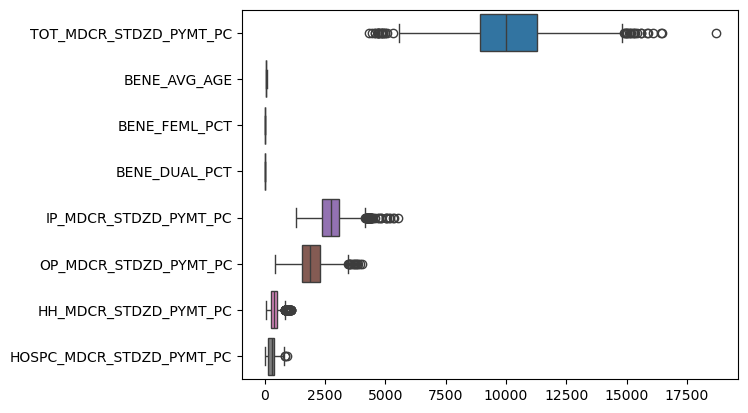

In [370]:
# States Dataframe Boxplot
sns.boxplot(df_states, orient = 'h')


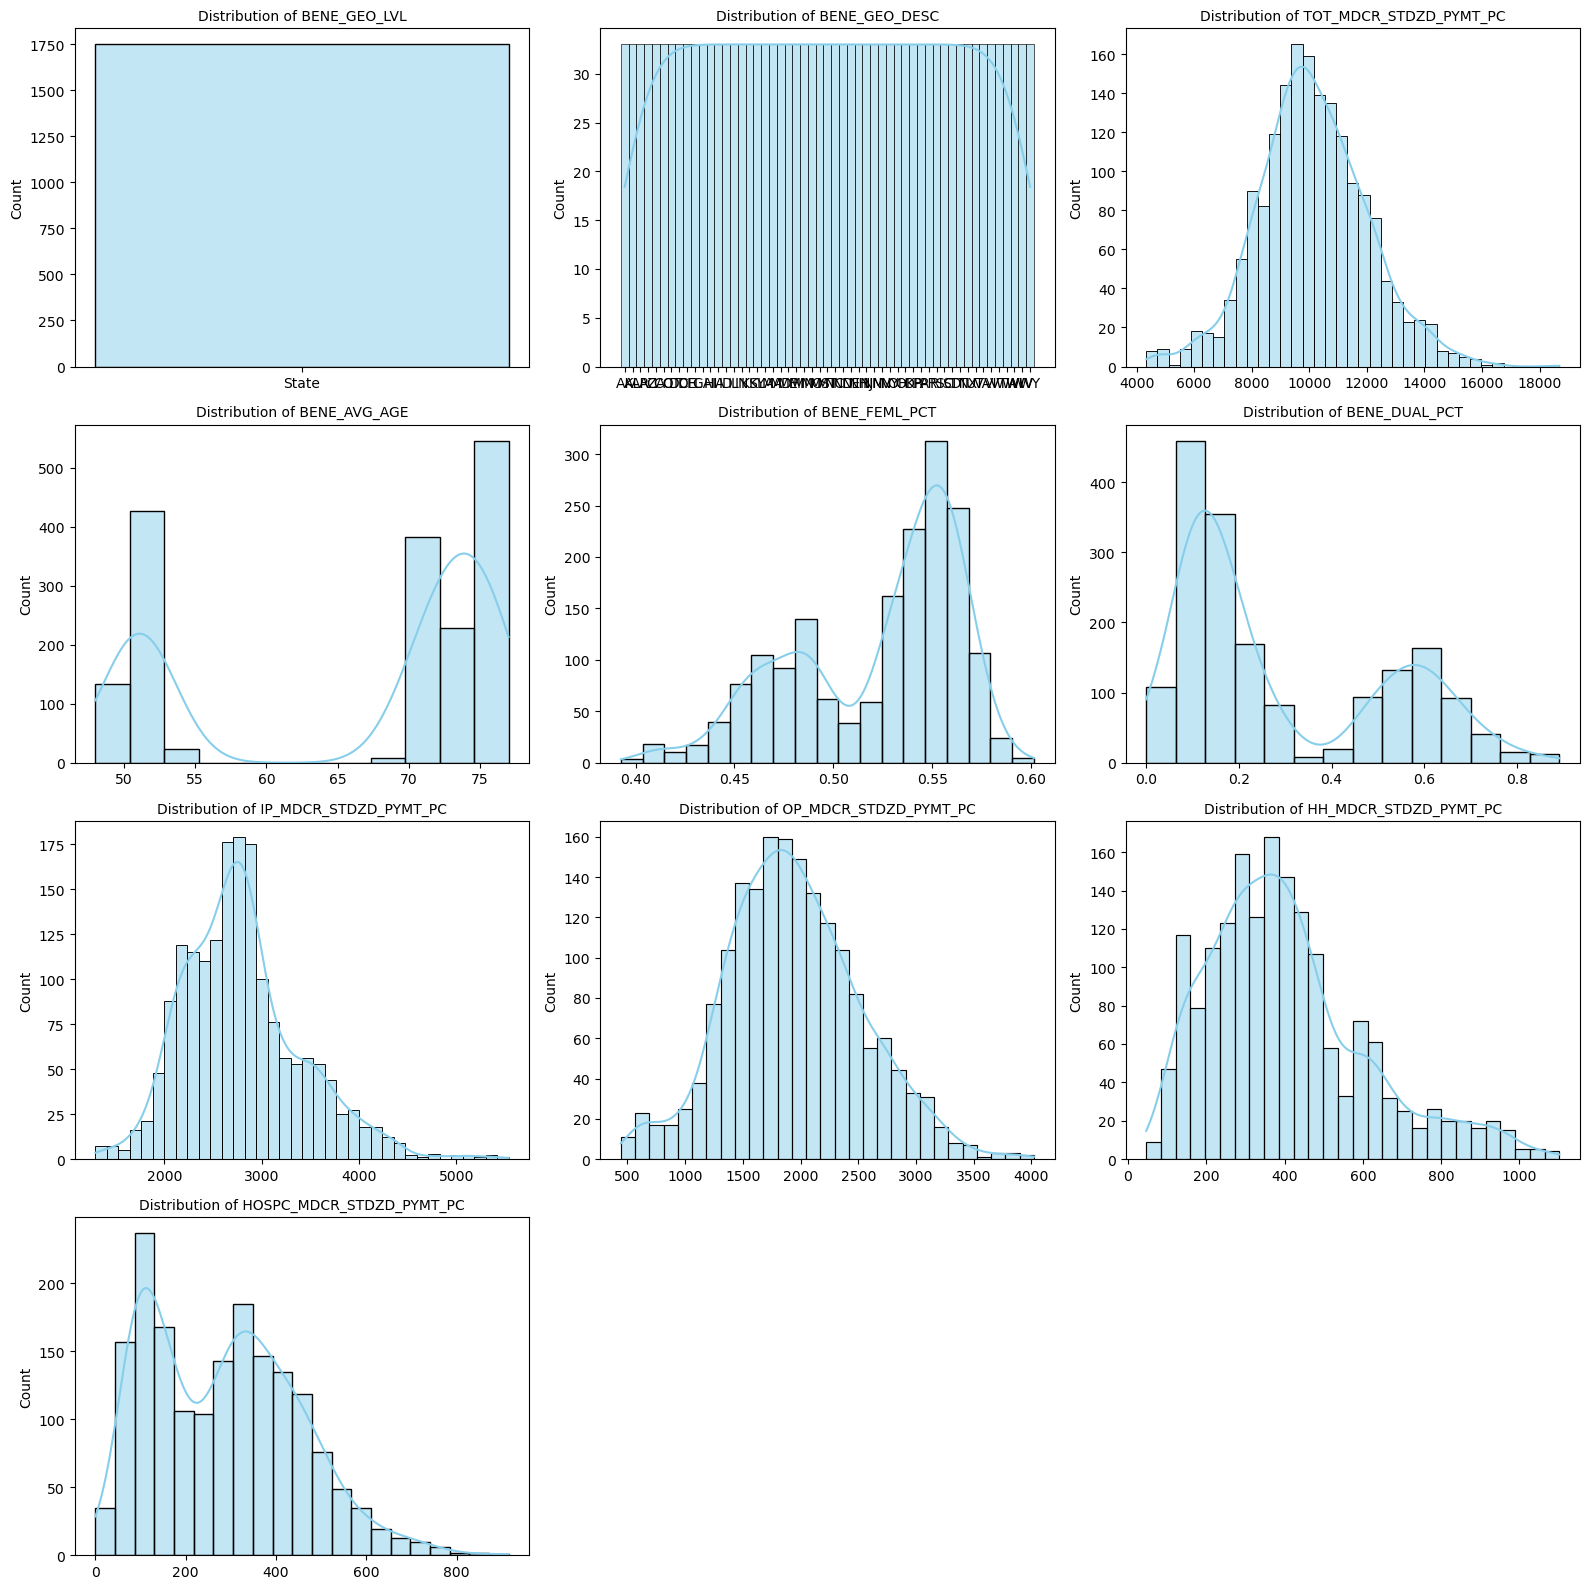

In [371]:
# States dataframe Distribution plot

num_cols_to_plot = len(df_states.columns)
nrows = (num_cols_to_plot + 2) // 3 

fig, axes = plt.subplots(nrows, 3, figsize=(16, nrows * 4))
axes = axes.flatten() 

for i, col in enumerate(df_states.columns):
    sns.histplot(data=df_states, x=col, kde=True, ax=axes[i], color="skyblue")
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel('') 

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The distribution plots of the States dataframe illustrate that the variables don't posses an normal distribution. Variables such as `BENE_DUAL_PCT`, `HH_MDCR_STDZD_PYMT_PC`,`HOSPC_MDCR_STDZD_PYMT_PC` are heavily right-skewed. Secondary, the boxplot conveys that `IP_MDCR_STDZD_PYMT_PC` and `OP_MDCR_STDZD_PYMT_PC` possess significant number of outliers. This suggests to maintain mathmetical integrity for model deployment, utilizing a single value imputation method where replacing missing values with the median value from the States dataframe would be best practice.

In [372]:
df_states= df_states.groupby(['BENE_GEO_DESC']).median(numeric_only= True).reset_index()
df_states

,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
0,AK,8112.50,71.0,0.5045,0.2263,2234.06,2066.64,155.84,108.24
1,AL,10854.21,71.0,0.5470,0.1922,2926.32,1652.15,685.25,577.53
2,AR,10252.13,71.0,0.5497,0.1909,2771.28,1766.14,461.96,352.38
3,AZ,9967.13,73.0,0.5308,0.1036,2335.46,1472.02,300.85,378.28
4,CA,10463.35,72.0,0.5397,0.3014,2685.00,1431.10,578.87,312.42
5,CO,9287.44,71.0,0.5298,0.1589,2244.89,1820.86,306.08,319.99
6,CT,11165.18,73.0,0.5582,0.2735,3058.34,2028.88,613.92,275.94
7,DC,10985.66,72.0,0.5737,0.3958,3206.08,1596.74,319.68,275.65
8,DE,10702.76,72.0,0.5553,0.1475,2631.49,1801.84,382.02,376.83
9,FL,12206.78,73.0,0.5466,0.1442,2975.25,1397.36,728.14,486.04


In [373]:
# Implementing Imputation method:

# Missing null values in the df_county dataframe are replaced with median values from the corresponding state

df_state_broadcasted = df_county[['STATE']].merge(
    df_states.drop_duplicates(subset=['BENE_GEO_DESC']),
    left_on='STATE',
    right_on='BENE_GEO_DESC',
    how='left'
).drop(columns=['BENE_GEO_DESC'])


df_state_broadcasted.index = df_county.index
df_county = df_county.fillna(df_state_broadcasted)

df_county

,BENE_GEO_LVL,STATE,BENE_GEO_DESC,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
0,County,AK,Aleutians East,4576.98,71.0,0.4359,0.2308,1365.81,1584.61,0.00,0.00
1,County,AK,Aleutians West,9712.25,69.0,0.4779,0.2721,3305.21,1811.12,155.84,0.00
2,County,AK,Anchorage,6665.07,70.0,0.5261,0.2493,2215.20,1105.13,156.75,129.51
3,County,AK,Bethel,6839.29,71.0,0.4958,0.5722,2356.21,1731.10,155.84,108.24
4,County,AK,Bristol Bay,6648.44,72.0,0.4231,0.1731,3294.30,913.22,155.84,0.00
...,...,...,...,...,...,...,...,...,...,...,...
35141,County,WY,Teton,9738.06,74.0,0.5008,0.0241,2221.06,3098.01,168.96,217.67
35142,County,WY,UNKNOWN,8792.96,72.0,0.5227,0.1195,2272.63,2077.99,210.30,117.66
35143,County,WY,Uinta,9348.27,72.0,0.4996,0.0934,2104.38,2739.90,441.77,214.64
35144,County,WY,Washakie,11287.97,74.0,0.5103,0.1008,1945.08,4471.63,78.06,241.56


In [374]:
df_county.isnull().any()

BENE_GEO_LVL                False
STATE                       False
BENE_GEO_DESC               False
TOT_MDCR_STDZD_PYMT_PC      False
BENE_AVG_AGE                False
BENE_FEML_PCT               False
BENE_DUAL_PCT               False
IP_MDCR_STDZD_PYMT_PC       False
OP_MDCR_STDZD_PYMT_PC       False
HH_MDCR_STDZD_PYMT_PC       False
HOSPC_MDCR_STDZD_PYMT_PC    False
dtype: bool

## Exploratory Data Analysis

In [375]:
df_county.describe()

,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
count,35146.000000,35146.000000,35146.000000,35146.000000,35146.000000,35146.000000,35146.000000,35146.000000
mean,10152.805512,71.819752,0.533675,0.188424,2618.560116,2091.478915,459.059774,364.311749
std,1963.782047,1.695140,0.022624,0.085893,494.391522,780.654494,319.039295,191.122769
min,2165.200000,63.000000,0.384600,0.000000,451.200000,357.630000,0.000000,0.000000
25%,8858.462500,71.000000,0.521600,0.127000,2305.240000,1551.530000,253.160000,228.630000
50%,9997.025000,72.000000,0.536400,0.173600,2617.695000,1945.845000,392.205000,339.220000
75%,11255.962500,73.000000,0.548700,0.232700,2916.392500,2461.420000,572.562500,470.720000
max,31729.190000,77.000000,0.636400,0.736200,14740.240000,17981.530000,4120.300000,1937.100000


In [376]:
df_county.corr(numeric_only= True)

,TOT_MDCR_STDZD_PYMT_PC,BENE_AVG_AGE,BENE_FEML_PCT,BENE_DUAL_PCT,IP_MDCR_STDZD_PYMT_PC,OP_MDCR_STDZD_PYMT_PC,HH_MDCR_STDZD_PYMT_PC,HOSPC_MDCR_STDZD_PYMT_PC
TOT_MDCR_STDZD_PYMT_PC,1.000000,0.142842,0.204671,0.040987,0.660875,0.358676,0.515900,0.466906
BENE_AVG_AGE,0.142842,1.000000,0.197863,-0.691824,-0.235991,0.319062,-0.159100,0.043899
BENE_FEML_PCT,0.204671,0.197863,1.000000,-0.098635,0.212410,-0.134703,0.169576,0.148911
BENE_DUAL_PCT,0.040987,-0.691824,-0.098635,1.000000,0.315127,-0.208664,0.275699,-0.061006
IP_MDCR_STDZD_PYMT_PC,0.660875,-0.235991,0.212410,0.315127,1.000000,-0.027668,0.394627,0.223979
OP_MDCR_STDZD_PYMT_PC,0.358676,0.319062,-0.134703,-0.208664,-0.027668,1.000000,-0.246531,-0.042998
HH_MDCR_STDZD_PYMT_PC,0.515900,-0.159100,0.169576,0.275699,0.394627,-0.246531,1.000000,0.422931
HOSPC_MDCR_STDZD_PYMT_PC,0.466906,0.043899,0.148911,-0.061006,0.223979,-0.042998,0.422931,1.000000


<Axes: >

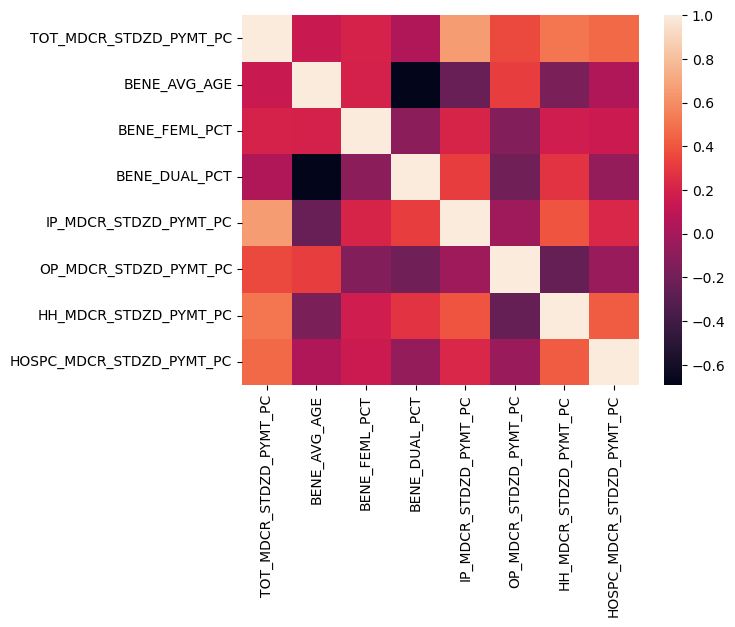

In [377]:
sns.heatmap(df_county.corr(numeric_only = True))

## Modeling

For this Project we will be evaluating three models and observe which model most accurately predicts Total Standardized Medicare Payments Per Capita. The models assessed using the open source Scikit-learn libraries include: Multivariable Linear Regression, Polynomial Regression and Ridge Regression. 

Feature Definitions:

Target variable (`y`): Total Standardized Medicare Payments Per Capita `TOT_MDCR_STDZD_PYMT_PC`

Patient demographic: 
- Average Age: `BENE_AVG_AGE`
- Percent Female: `BENE_FEML_PCT`
- Percent Eligible for Medicaid: `BENE_DUAL_PCT`

Please note that in the project that the patient demographic feauture group is defined as `x` 

System Utilization:
- IP Per Capita Standardized Medicare Payment: `IP_MDCR_STDZD_PYMT_PC`
- OP Per Capita Standardized Medicare Payment: `OP_MDCR_STDZD_PYMT_PC`
- HH Per Capita Standardized Medicare Payment: `HH_MDCR_STDZD_PYMT_PC`
- Hospice Per Capita Standardized Medicare Payment `HOSPC_MDCR_STDZD_PYMT_PC`

Please note that in the project that the System Utilization feature group is defined as `x1`

Baseline:
- The baseline feature group is a combination of all variables less the target variable

Please note that in the project that the System Utilization feature group is defined as `x2`




In [378]:
# Defining Feauture Groups

x = df_county[['BENE_AVG_AGE',
 'BENE_FEML_PCT',
 'BENE_DUAL_PCT',]]

x1 = df_county[[ 'IP_MDCR_STDZD_PYMT_PC',
 'OP_MDCR_STDZD_PYMT_PC',
 'HH_MDCR_STDZD_PYMT_PC',
 'HOSPC_MDCR_STDZD_PYMT_PC']]

x2 = df_county.drop(columns=['TOT_MDCR_STDZD_PYMT_PC','BENE_GEO_LVL','STATE','BENE_GEO_DESC'])

y= df_county['TOT_MDCR_STDZD_PYMT_PC']



## Feature Group 1: Patient Demographic

In [379]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size = 0.2)
print('Training set shape:', X_train.shape, y_train.shape)
print('Test set shape:', X_test.shape, y_test.shape)

Training set shape: (28116, 3) (28116,)
Test set shape: (7030, 3) (7030,)


In [380]:
#Adding standardscaler
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

### Linear Regression Analysis

In [381]:
model= LinearRegression()
model.fit(X_train_scaler, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[572.53,349.83,518.27]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.016e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[221.78,163.61, 91.62]"


In [382]:
y_hat_group1= model.predict(X_test_scaler)
y_hat_group1.shape

(7030,)

In [383]:
r2= r2_score(y_test, y_hat_group1)
mse= mean_squared_error(y_test,y_hat_group1)
mae= mean_absolute_error(y_test, y_hat_group1)


print(f'R2_score: {r2}')
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')


R2_score: 0.06932550872699805
Mean Squared Error: 3514025.1605402594
Mean Absolute Error: 1426.1032272148454


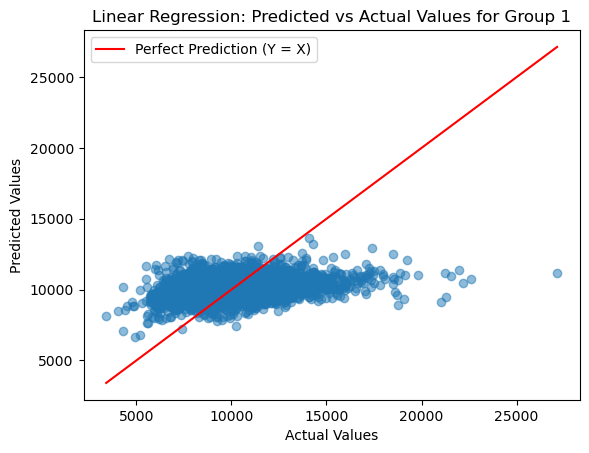

In [384]:
# Predicted vs actual values for linear regression

plt.scatter(y_test, y_hat_group1, alpha = 0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color ='red', label='Perfect Prediction (Y = X)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Predicted vs Actual Values for Group 1')
plt.legend()
plt.show()

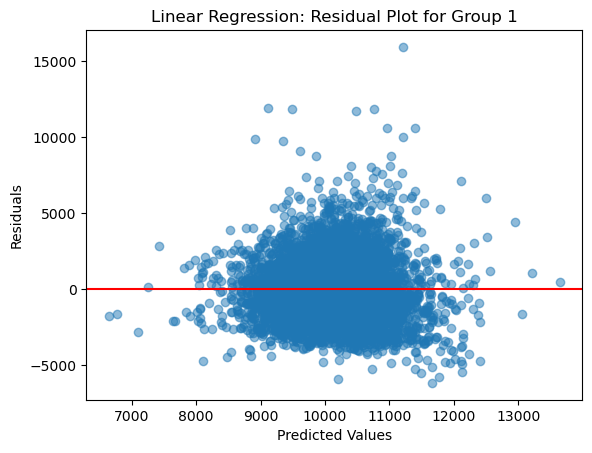

In [385]:
# Residual plot for Predicted vs Actual values for linear Regression

plt.scatter(y_hat_group1, y_test - y_hat_group1 , alpha= 0.5)
plt.axhline(y= 0, color ='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Plot for Group 1')
plt.show()

### Polynomial Regression Analysis

In [386]:
def find_best_poly_degree(X_train_scaled, X_test_scaled, y_train, y_test, degrees=range(2, 7), group_name=''):
    """
    Tests polynomial degrees on the given train/test data, plots train vs test
    R-squared to visualize the bias-variance tradeoff, and returns the degree
    with the highest test R-squared.
    """
    train_r2_scores = []
    test_r2_scores = []

    for degree in degrees:
        poly_test = PolynomialFeatures(degree=degree)
        X_poly_train_test = poly_test.fit_transform(X_train_scaled)
        X_poly_test_test = poly_test.transform(X_test_scaled)

        model_test = LinearRegression()
        model_test.fit(X_poly_train_test, y_train)

        train_r2_scores.append(r2_score(y_train, model_test.predict(X_poly_train_test)))
        test_r2_scores.append(r2_score(y_test, model_test.predict(X_poly_test_test)))

    plt.figure(figsize=(8, 5))
    plt.plot(degrees, train_r2_scores, marker='o', label='Train R-squared', color='steelblue')
    plt.plot(degrees, test_r2_scores, marker='o', label='Test R-squared', color='coral')
    plt.xlabel('Polynomial Degree')
    plt.ylabel('R-squared Score')
    plt.title(f'Train vs Test R-squared by Polynomial Degree ({group_name})')
    plt.legend()
    plt.xticks(list(degrees))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    best_degree = degrees[test_r2_scores.index(max(test_r2_scores))]
    print(f'Best polynomial degree for {group_name}: {best_degree}')
    print(f'Test R-squared at best degree: {max(test_r2_scores):.4f}')

    return best_degree

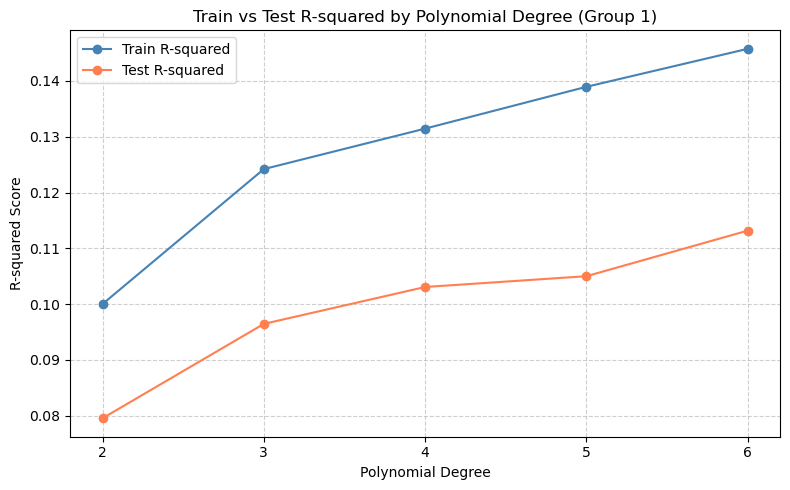

Best polynomial degree for Group 1: 6
Test R-squared at best degree: 0.1132


In [387]:
best_degree_group1 = find_best_poly_degree(X_train_scaler, X_test_scaler, y_train, y_test, group_name='Group 1')

In [388]:
poly= PolynomialFeatures()
X_poly_train = poly.fit_transform(X_train_scaler)
X_test_poly = poly.transform(X_test_scaler)
poly.fit(X_poly_train, y_train)
model.fit(X_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ 0. ,594.35,282.25,...,-86.61, 36.45, 5.52]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.019e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,9
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](10,)","[465.45,329.92,263.13,..., 89.12, 72.91, 0. ]"


In [389]:
y_hat_group1_poly = model.predict(X_test_poly)

r2_poly= r2_score(y_test, y_hat_group1_poly)
mse_poly= mean_squared_error(y_test,y_hat_group1_poly)
mae_poly= mean_absolute_error(y_test, y_hat_group1_poly)


print(f'R2_score: {r2_poly}')
print(f'Mean Squared Error: {mse_poly}')
print(f'Mean Absolute Error: {mae_poly}')

R2_score: 0.0795502118763024
Mean Squared Error: 3475418.897595881
Mean Absolute Error: 1416.0204423504508


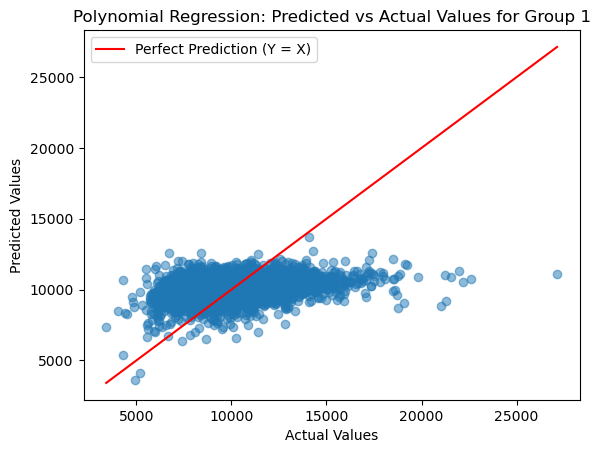

In [390]:
# Predicted vs actual values for Polynomial regression

plt.scatter(y_test, y_hat_group1_poly, alpha = 0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color ='red',label='Perfect Prediction (Y = X)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Polynomial Regression: Predicted vs Actual Values for Group 1')
plt.legend()
plt.show()

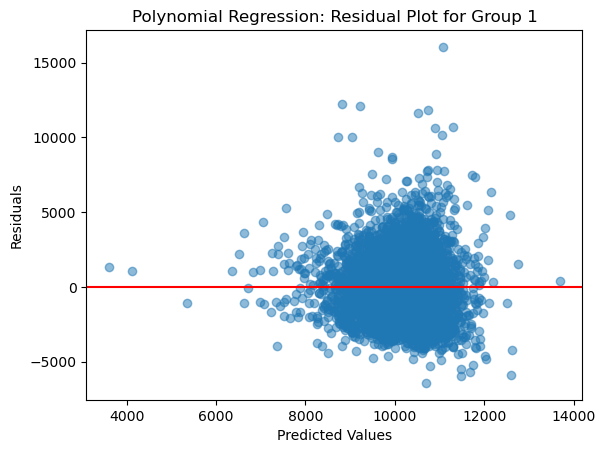

In [391]:
# Residual plot for Predicted vs Actual values for Polynomial Regression

plt.scatter(y_hat_group1_poly, y_test - y_hat_group1_poly , alpha = 0.5)
plt.axhline(y= 0, color ='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Polynomial Regression: Residual Plot for Group 1')
plt.show()

## Feature Group 2: Service Utilization

In [392]:
# Setting Standard Scaler and Train Test strategy

X1_train, X1_test, y_train, y_test = train_test_split(x1,y, test_size = 0.2)

X1_train_scaler = scaler.fit_transform(X1_train)
X1_test_scaler = scaler.transform(X1_test)

print('Training set shape:', X1_train.shape, y_train.shape)
print('Test set shape:', X1_test.shape, y_test.shape)

Training set shape: (28116, 4) (28116,)
Test set shape: (7030, 4) (7030,)


### Linear Regression Analysis

In [393]:
model.fit(X1_train_scaler, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[956.96,919.55,665.97,462.2 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.015e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[221.88,167.41,148.11,115.2 ]"


In [394]:
y_hat_group2= model.predict(X1_test_scaler)
y_hat_group2.shape

(7030,)

In [395]:
r2_group2= r2_score(y_test, y_hat_group2)
mse_group2= mean_squared_error(y_test,y_hat_group2)
mae_group2= mean_absolute_error(y_test, y_hat_group2)

print(f'R2_score: {r2_group2}')
print(f'Mean Squared Error: {mse_group2}')
print(f'Mean Absolute Error: {mae_group2}')

R2_score: 0.7828097739105452
Mean Squared Error: 823322.0510551711
Mean Absolute Error: 658.5340805142412


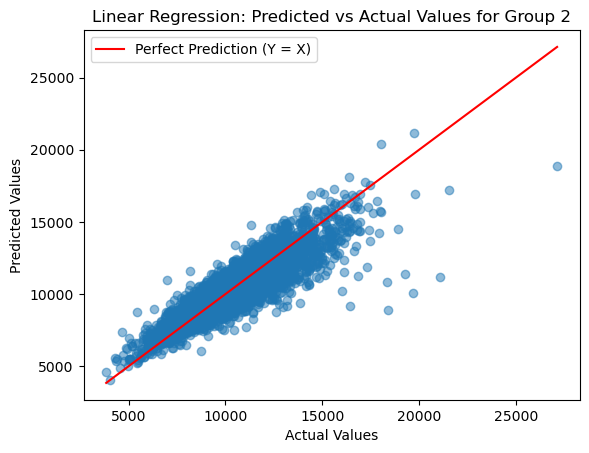

In [396]:
# Predicted vs actual values for linear regression

plt.scatter(y_test, y_hat_group2, alpha = 0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color ='red',label='Perfect Prediction (Y = X)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Predicted vs Actual Values for Group 2')
plt.legend()
plt.show()

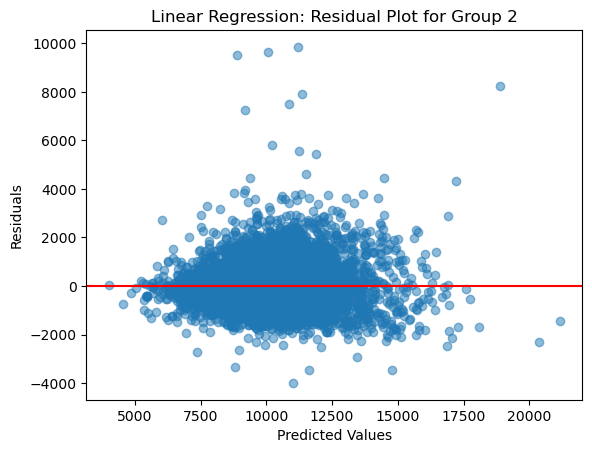

In [397]:
# Residual plot for Predicted vs Actual values for linear Regression

plt.scatter(y_hat_group2, y_test - y_hat_group2 , alpha = 0.5)
plt.axhline(y= 0, color ='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Plot for Group 2')
plt.show()

### Polynomial Regression Analysis

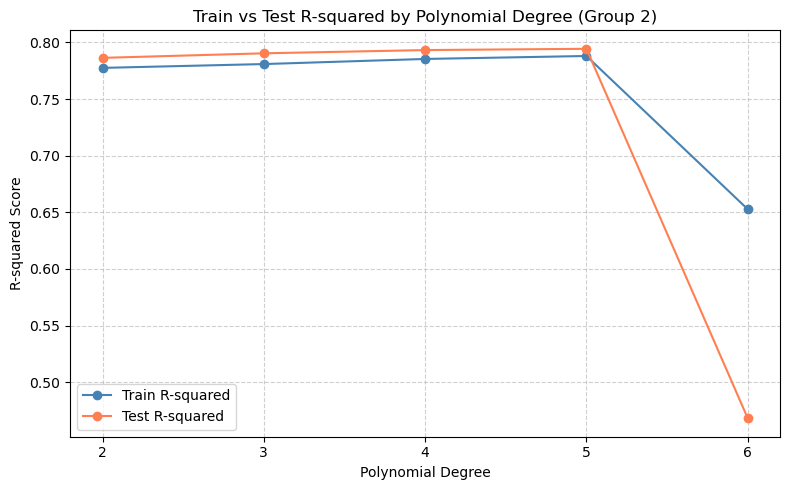

Best polynomial degree for Group 2: 5
Test R-squared at best degree: 0.7943


In [398]:
best_degree_group2 = find_best_poly_degree(X1_train_scaler, X1_test_scaler, y_train, y_test, group_name='Group 2')

In [399]:
# Setting Standard Scaler and fitting model
poly = PolynomialFeatures(degree=best_degree_group2)
X1_poly_train = poly.fit_transform(X1_train_scaler)
X1_test_poly = poly.transform(X1_test_scaler)
poly.fit(X1_poly_train, y_train)
model.fit(X1_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](126,)","[ -0. ,982.85,921.23,..., 2.82, 0.23, 0.12]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.014e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,126
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,125
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](126,)","[9137600.51,3477424.51, 416718.38,..., 30.51, 27.56, 0. ]"


In [400]:
y_hat_group2_poly= model.predict(X1_test_poly)

r2_group2_poly= r2_score(y_test, y_hat_group2_poly)
mse_group2_poly= mean_squared_error(y_test,y_hat_group2_poly)
mae_group2_poly= mean_absolute_error(y_test, y_hat_group2_poly)


print(f'R2_score: {r2_group2_poly}')
print(f'Mean Squared Error: {mse_group2_poly}')
print(f'Mean Absolute Error: {mae_group2_poly}')

R2_score: 0.7943207313663111
Mean Squared Error: 779686.4544045805
Mean Absolute Error: 645.0854484254412


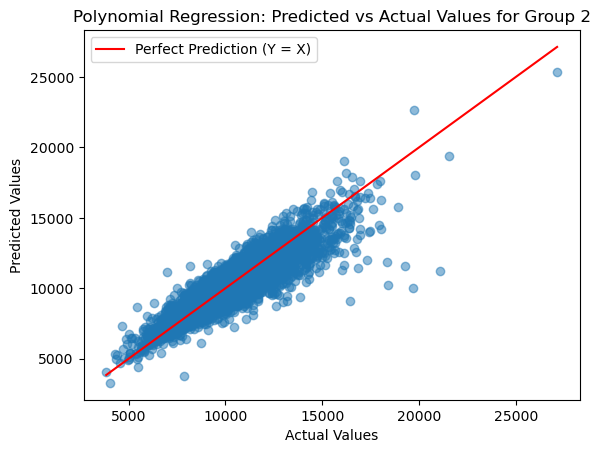

In [401]:
# Predicted vs actual values for Polynomial Regression

plt.scatter(y_test, y_hat_group2_poly , alpha =0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color ='red',label='Perfect Prediction (Y = X)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Polynomial Regression: Predicted vs Actual Values for Group 2')
plt.legend()
plt.show()

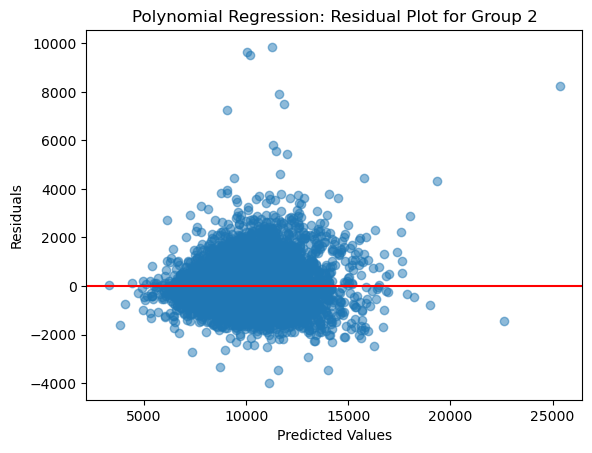

In [402]:
# Residual plot for Predicted vs Actual values for Polynomial Regression

plt.scatter(y_hat_group2_poly, y_test - y_hat_group2 , alpha= 0.5)
plt.axhline(y= 0, color ='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Polynomial Regression: Residual Plot for Group 2')
plt.show()

## Feature Group 3: Baseline

In [403]:
# Setting StandadScaler and Train Test Strategy

X2_train, X2_test, y_train, y_test = train_test_split(x2,y, test_size = 0.2)

scaler_group3 = StandardScaler()
X2_train_scaler = scaler_group3.fit_transform(X2_train)
X2_test_scaler = scaler_group3.transform(X2_test)

print('Training set shape:', X2_train.shape, y_train.shape)
print('Test set shape:', X2_test.shape, y_test.shape)

Training set shape: (28116, 7) (28116,)
Test set shape: (7030, 7) (7030,)


### Linear Regression Analysis

In [404]:
model.fit(X2_train_scaler,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[356.04, 47.1 , 15.74,...,814.33,675.66,414.6 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.015e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,7
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[251.78,212.93,167.26,...,120.9 ,116.17, 84.87]"


In [405]:
y_hat_group3= model.predict(X2_test_scaler)
y_hat_group3.shape

(7030,)

In [406]:
r2_group3= r2_score(y_test, y_hat_group3)
mse_group3= mean_squared_error(y_test,y_hat_group3)
mae_group3= mean_absolute_error(y_test, y_hat_group3)

print(f'R2_score: {r2_group3}')
print(f'Mean Squared Error: {mse_group3}')
print(f'Mean Absolute Error: {mae_group3}')


R2_score: 0.8112288249071395
Mean Squared Error: 707725.9133416207
Mean Absolute Error: 598.6614610204689


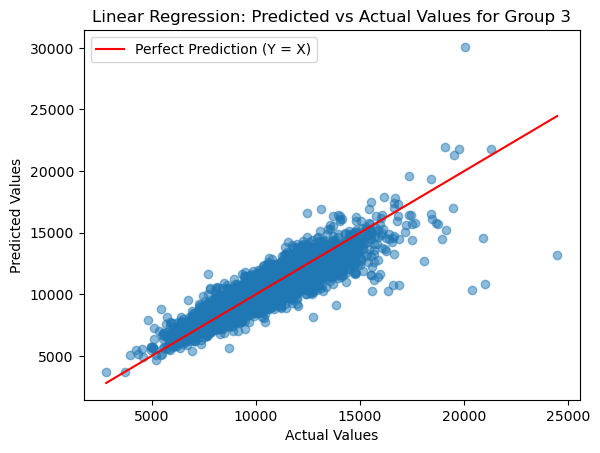

In [407]:
# Predicted vs actual values for linear regression

plt.scatter(y_test, y_hat_group3 , alpha =0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color ='red',label='Perfect Prediction (Y = X)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Predicted vs Actual Values for Group 3')
plt.legend()
plt.show()

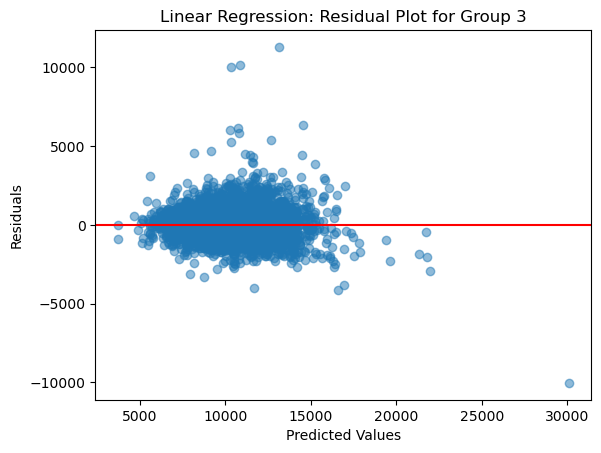

In [408]:
# Residual plot for Predicted vs Actual values for linear Regression

plt.scatter(y_hat_group3, y_test - y_hat_group3 , alpha= 0.5)
plt.axhline(y= 0, color ='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Plot for Group 3')
plt.show()

### Polynomial Regression Analysis

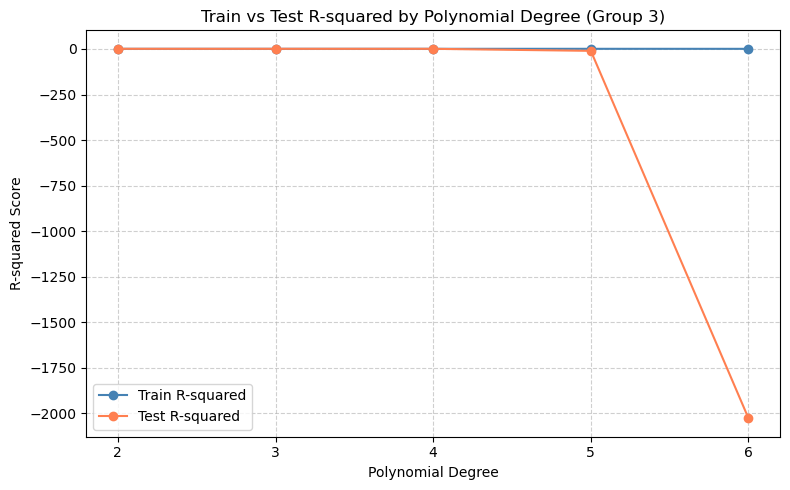

Best polynomial degree for Group 3: 3
Test R-squared at best degree: 0.8332


In [409]:
best_degree_group3 = find_best_poly_degree(X2_train_scaler, X2_test_scaler, y_train, y_test, group_name='Group 3')

In [410]:
poly = PolynomialFeatures(degree=best_degree_group3)
X2_poly_train = poly.fit_transform(X2_train_scaler)
X2_test_poly = poly.transform(X2_test_scaler)
poly.fit(X2_poly_train, y_train)
model.fit(X2_poly_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](120,)","[ -0. ,490.21,-29.21,..., 6.26, -6.41, -5.51]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.011e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,120
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,119
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](120,)","[15259.5 , 9555.03, 4951.54,..., 39.09, 33.43, 0. ]"


In [411]:
y_hat_group3_poly= model.predict(X2_test_poly)

r2_group3_poly= r2_score(y_test, y_hat_group3_poly)
mse_group3_poly= mean_squared_error(y_test,y_hat_group3_poly)
mae_group3_poly= mean_absolute_error(y_test, y_hat_group3_poly)


print(f'R2_score: {r2_group3_poly}')
print(f'Mean Squared Error: {mse_group3_poly}')
print(f'Mean Absolute Error: {mae_group3_poly}')

R2_score: 0.8331936576840685
Mean Squared Error: 625377.1048924436
Mean Absolute Error: 561.0881861099781


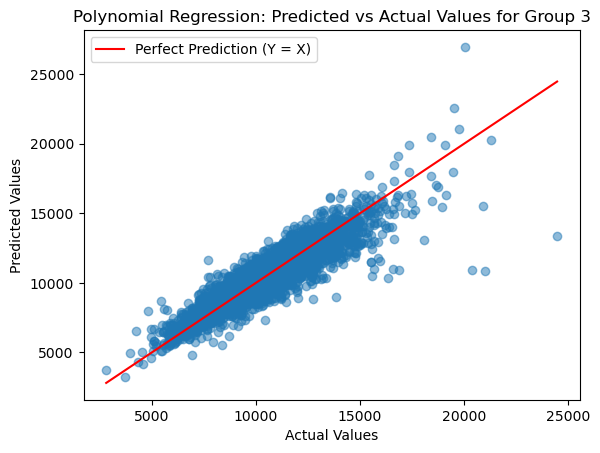

In [412]:
# Predicted vs actual values for Polynomial Regression

plt.scatter(y_test, y_hat_group3_poly , alpha =0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color ='red',label='Perfect Prediction (Y = X)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Polynomial Regression: Predicted vs Actual Values for Group 3')
plt.legend()
plt.show()

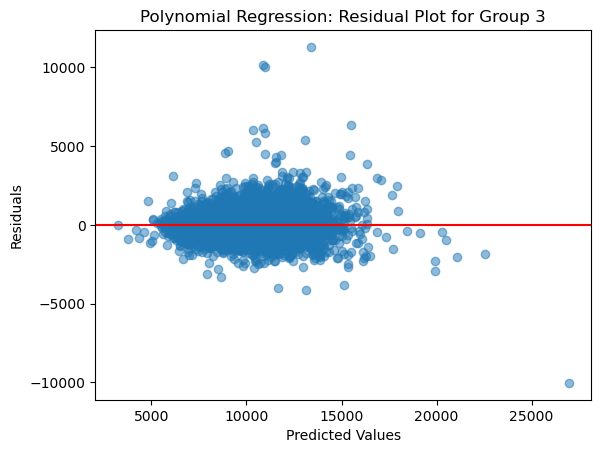

In [413]:
# Residual plot for Predicted vs Actual values for Polynomial Regression

plt.scatter(y_hat_group3_poly, y_test - y_hat_group3 , alpha= 0.5)
plt.axhline(y= 0, color ='red')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Polynomial Regression: Residual Plot for Group 3')
plt.show()

## Linear Regression Comparison

Comparison between the performance of the linear regression across the feature groups

In [414]:
linear_performance_metrics = pd.DataFrame(
    { 'Metric': ['R-squared', 'MSE' , 'MAE'],
      'Group 1': [r2, mse, mae],
      'Group 2': [r2_group2, mse_group2, mae_group2],
      'Group 3': [r2_group3, mse_group3, mae_group3]})

print('Linear Regression Performance Metrics:')
print(linear_performance_metrics)

Linear Regression Performance Metrics:
      Metric       Group 1        Group 2        Group 3
0  R-squared  6.932551e-02       0.782810       0.811229
1        MSE  3.514025e+06  823322.051055  707725.913342
2        MAE  1.426103e+03     658.534081     598.661461


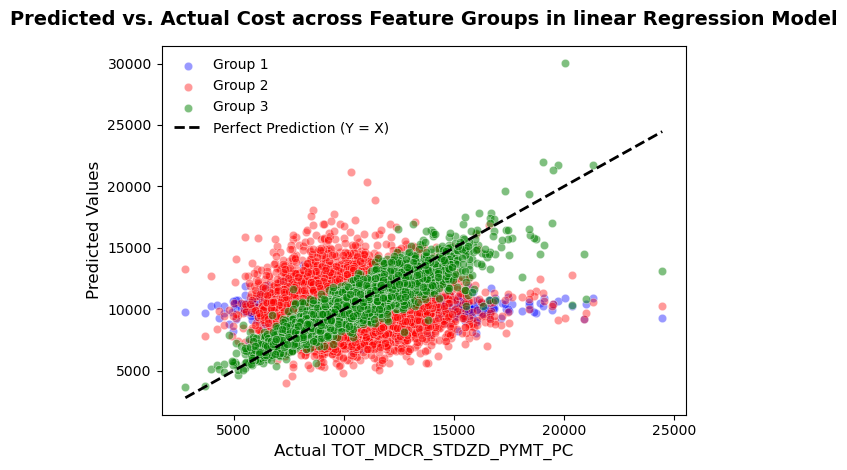

In [415]:
# Linear regression scatterplot comparison

sns.scatterplot(x = y_test, y= y_hat_group1, color= 'blue', alpha =0.4, label = 'Group 1')
sns.scatterplot(x = y_test, y= y_hat_group2, color= 'red', alpha = 0.4, label = 'Group 2')
sns.scatterplot(x = y_test, y= y_hat_group3, color= 'green', alpha = 0.5, label = 'Group 3')



plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color='black', linestyle='--', linewidth=2, label='Perfect Prediction (Y = X)')


plt.title('Predicted vs. Actual Cost across Feature Groups in linear Regression Model', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Actual TOT_MDCR_STDZD_PYMT_PC', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)


plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()

plt.show()

## Polynomial Regression Comparison

Comparison between the performance of the polynomial regression across the feature groups

In [416]:
polynomial_performance_metrics = pd.DataFrame(
    { 'Metric': ['R-squared', 'MSE' , 'MAE'],
      'Group 1': [r2_poly, mse_poly, mae_poly],
      'Group 2': [r2_group2_poly, mse_group2_poly, mae_group2_poly],
      'Group 3': [r2_group3_poly, mse_group3_poly, mae_group3_poly]})

print('Polynomial Regression Performance Metrics:')
print(polynomial_performance_metrics)

Polynomial Regression Performance Metrics:
      Metric       Group 1        Group 2        Group 3
0  R-squared  7.955021e-02       0.794321       0.833194
1        MSE  3.475419e+06  779686.454405  625377.104892
2        MAE  1.416020e+03     645.085448     561.088186


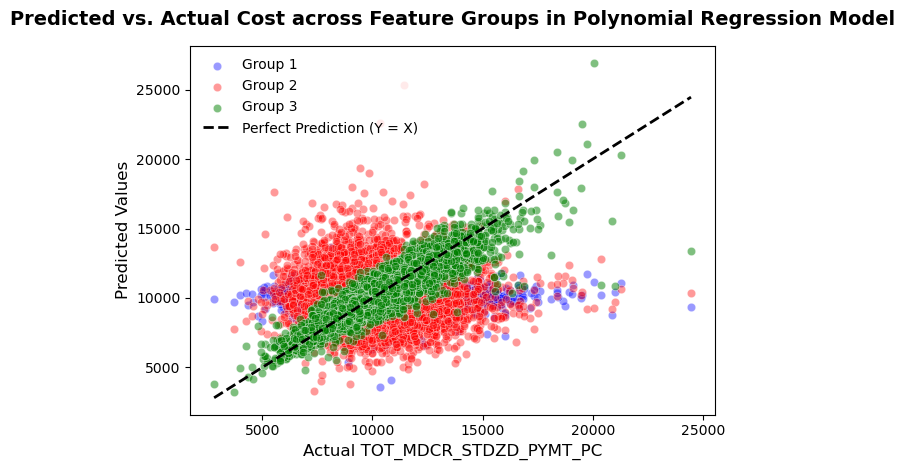

In [417]:
# Comparison for Polynomial scatterplot distribution

sns.scatterplot(x = y_test, y= y_hat_group1_poly, color= 'blue', alpha =0.4, label = 'Group 1')
sns.scatterplot(x = y_test, y= y_hat_group2_poly, color= 'red', alpha = 0.4, label = 'Group 2')
sns.scatterplot(x = y_test, y= y_hat_group3_poly, color= 'green', alpha = 0.5, label= 'Group 3')


plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], color='black', linestyle='--', linewidth=2, label='Perfect Prediction (Y = X)')


plt.title('Predicted vs. Actual Cost across Feature Groups in Polynomial Regression Model', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Actual TOT_MDCR_STDZD_PYMT_PC', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)


plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()

plt.show()

## Ridge Regression Analysis

### Hyperparameter tuning 

The `tune_ridge_model` function performs hyperparameter tuning for the Ridge regression model using `GridSearchCV`. This function will take scaled training data (X) and the target variable (y) as input, and return the optimal alpha found.


In [418]:
def tune_ridge_model(X_train_scaled, y_train):
   
    param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
    grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='r2')
    grid_search.fit(X_train_scaled, y_train)

    print(f"Best alpha found: {grid_search.best_params_['alpha']}")
    return grid_search.best_estimator_

print("tune_ridge_model function defined.")

tune_ridge_model function defined.


#### Feature Group 1 (Patient Demographic) Tuning

Applying the defined hyperparameter tuning function to `x` and `y` (from feature group 1) to find the best `alpha` for this group and evaluate the model's performance.

In [419]:
# Setting data in StandardScaler, tune the Ridge Model for feature group 1 and generate predictions

X_train_group1, X_test_group1, y_train_group1, y_test_group1 = train_test_split(x, y, test_size=0.2)

scaler_group1 = StandardScaler()
X_train_scaled_group1 = scaler_group1.fit_transform(X_train_group1)
X_test_scaled_group1 = scaler_group1.transform(X_test_group1)

best_ridge_model_group1 = tune_ridge_model(X_train_scaled_group1, y_train_group1)

y_pred_group1_ridge = best_ridge_model_group1.predict(X_test_scaled_group1)

print("Ridge model for Feature Group 1 tuned and predictions made.")

Best alpha found: 10
Ridge model for Feature Group 1 tuned and predictions made.


In [420]:
r2_ridge_group1 = r2_score(y_test_group1, y_pred_group1_ridge)
mse_ridge_group1 = mean_squared_error(y_test_group1, y_pred_group1_ridge)
mae_ridge_group1 = mean_absolute_error(y_test_group1, y_pred_group1_ridge)

print(f'R2_score for Ridge Group 1: {r2_ridge_group1}')
print(f'Mean Squared Error for Ridge Group 1: {mse_ridge_group1}')
print(f'Mean Absolute Error for Ridge Group 1: {mae_ridge_group1}')

R2_score for Ridge Group 1: 0.08743722454315495
Mean Squared Error for Ridge Group 1: 3542014.3875030237
Mean Absolute Error for Ridge Group 1: 1452.616124476742


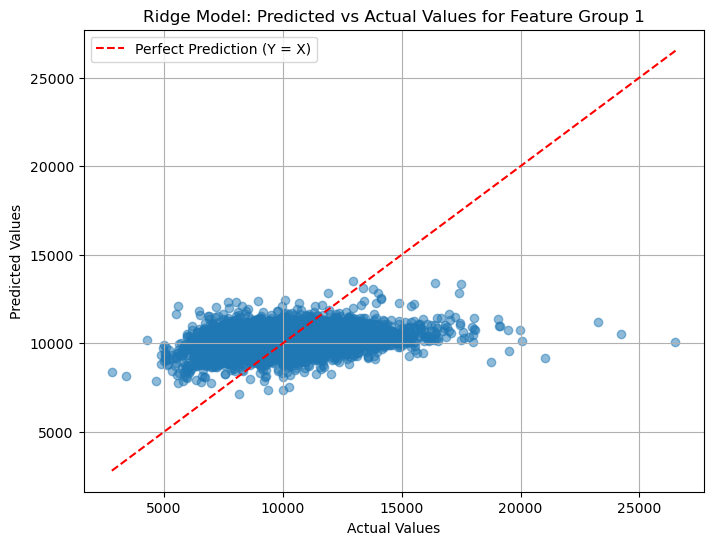

In [421]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_group1, y_pred_group1_ridge, alpha=0.5)
plt.plot([y_test_group1.min(), y_test_group1.max()], [y_test_group1.min(), y_test_group1.max()], color='red', linestyle='--',label='Perfect Prediction (Y = X)')
plt.title('Ridge Model: Predicted vs Actual Values for Feature Group 1')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()
plt.show()

#### Feature Group 2 (Service Utilization) Tuning

Applying the defined hyperparameter tuning function to `x1` and `y` (from feature group 2) to find the best `alpha` for this group and evaluate the model's performance.

In [422]:
# Setting data in StandardScaler, tune the Ridge Model for feature group 2 and generate predictions

X_train_group2, X_test_group2, y_train_group2, y_test_group2 = train_test_split(x1, y, test_size=0.2, random_state=42)

scaler_group2 = StandardScaler()
X_train_scaled_group2 = scaler_group2.fit_transform(X_train_group2)
X_test_scaled_group2 = scaler_group2.transform(X_test_group2)

best_ridge_model_group2 = tune_ridge_model(X_train_scaled_group2, y_train_group2)

y_pred_group2_ridge = best_ridge_model_group2.predict(X_test_scaled_group2)

print("Ridge model for Feature Group 2 tuned and predictions made.")

Best alpha found: 10
Ridge model for Feature Group 2 tuned and predictions made.


In [423]:
r2_ridge_group2 = r2_score(y_test_group2, y_pred_group2_ridge)
mse_ridge_group2 = mean_squared_error(y_test_group2, y_pred_group2_ridge)
mae_ridge_group2 = mean_absolute_error(y_test_group2, y_pred_group2_ridge)

print(f'R2_score for Ridge Group 2: {r2_ridge_group2}')
print(f'Mean Squared Error for Ridge Group 2: {mse_ridge_group2}')
print(f'Mean Absolute Error for Ridge Group 2: {mae_ridge_group2}')

R2_score for Ridge Group 2: 0.7635858914276348
Mean Squared Error for Ridge Group 2: 924750.6631120068
Mean Absolute Error for Ridge Group 2: 665.3830270700086


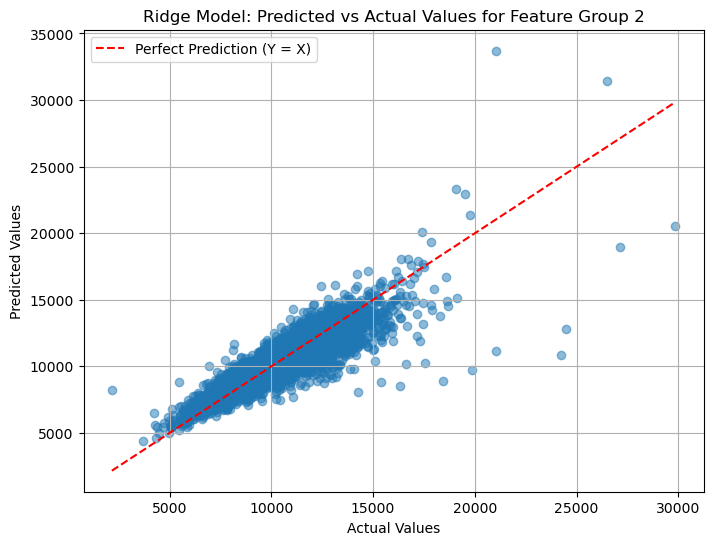

In [424]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_group2, y_pred_group2_ridge, alpha=0.5)
plt.plot([y_test_group2.min(), y_test_group2.max()], [y_test_group2.min(), y_test_group2.max()], color='red', linestyle='--',label='Perfect Prediction (Y = X)')
plt.title('Ridge Model: Predicted vs Actual Values for Feature Group 2')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()
plt.show()

#### Feature Group 3 (Baseline) Tuning

Applying the defined hyperparameter tuning function to `x2` and `y` (from feature group 3) to find the best `alpha` for this group and evaluate the model's performance.

In [425]:
X_train_group3, X_test_group3, y_train_group3, y_test_group3 = train_test_split(x2, y, test_size=0.2, random_state=42)

scaler_group3 = StandardScaler()
X_train_scaled_group3 = scaler_group3.fit_transform(X_train_group3)
X_test_scaled_group3 = scaler_group3.transform(X_test_group3)

best_ridge_model_group3 = tune_ridge_model(X_train_scaled_group3, y_train_group3)

y_pred_group3_ridge = best_ridge_model_group3.predict(X_test_scaled_group3)

print("Ridge model for Feature Group 3 tuned and predictions made.")

Best alpha found: 10
Ridge model for Feature Group 3 tuned and predictions made.


In [426]:
r2_ridge_group3 = r2_score(y_test_group3, y_pred_group3_ridge)
mse_ridge_group3 = mean_squared_error(y_test_group3, y_pred_group3_ridge)
mae_ridge_group3 = mean_absolute_error(y_test_group3, y_pred_group3_ridge)

print(f'R2_score for Ridge Group 3: {r2_ridge_group3}')
print(f'Mean Squared Error for Ridge Group 3: {mse_ridge_group3}')
print(f'Mean Absolute Error for Ridge Group 3: {mae_ridge_group3}')

R2_score for Ridge Group 3: 0.7912030882710933
Mean Squared Error for Ridge Group 3: 816724.02608723
Mean Absolute Error for Ridge Group 3: 611.0743882888256


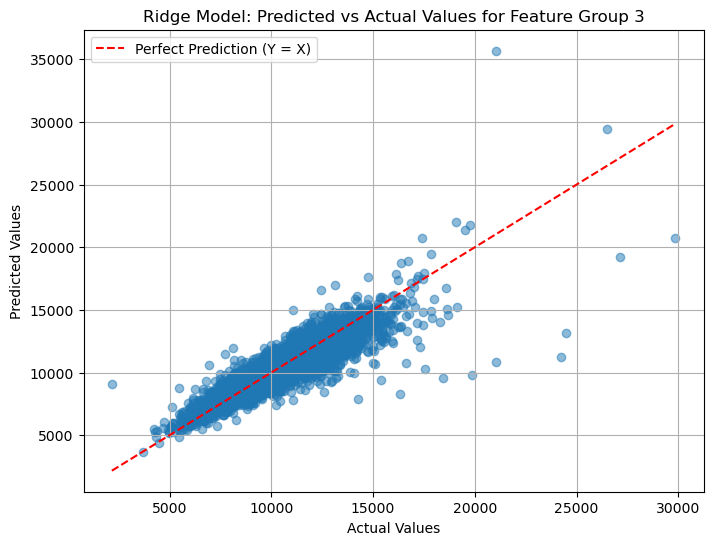

In [427]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_group3, y_pred_group3_ridge, alpha=0.5)
plt.plot([y_test_group3.min(), y_test_group3.max()], [y_test_group3.min(), y_test_group3.max()], color='red', linestyle='--', label='Perfect Prediction (Y = X)')
plt.title('Ridge Model: Predicted vs Actual Values for Feature Group 3')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()
plt.show()

## Ridge Model Comparison

Comparison between the performance of the Ridge Model across the feature groups

In [428]:
performance_metrics = pd.DataFrame({
    'Metric': ['R-squared', 'MSE', 'MAE'],
    'Group 1': [r2_ridge_group1, mse_ridge_group1, mae_ridge_group1],
    'Group 2': [r2_ridge_group2, mse_ridge_group2, mae_ridge_group2],
    'Group 3': [r2_ridge_group3, mse_ridge_group3, mae_ridge_group3]
})

print("Performance Metrics Across Feature Groups:")
print(performance_metrics)

Performance Metrics Across Feature Groups:
      Metric       Group 1        Group 2        Group 3
0  R-squared  8.743722e-02       0.763586       0.791203
1        MSE  3.542014e+06  924750.663112  816724.026087
2        MAE  1.452616e+03     665.383027     611.074388


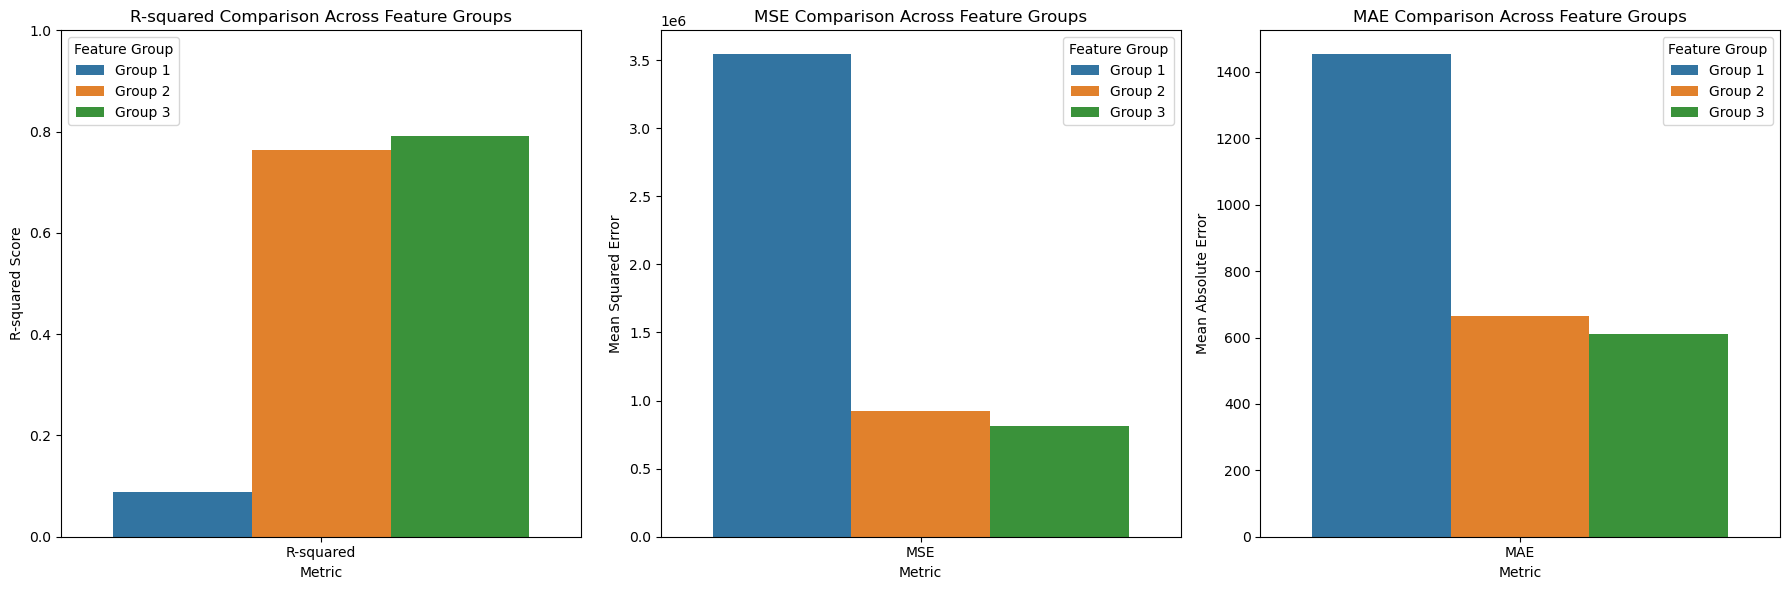

In [429]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Bar plot for R-squared
sns.barplot(x='Metric', y='value', hue='variable', data=pd.melt(performance_metrics[performance_metrics['Metric'] == 'R-squared'], id_vars='Metric'), ax=axes[0])
axes[0].set_title('R-squared Comparison Across Feature Groups')
axes[0].set_ylabel('R-squared Score')
axes[0].set_ylim(0, 1.0)
axes[0].legend(title='Feature Group', loc='upper left')

# Bar plot for MSE
sns.barplot(x='Metric', y='value', hue='variable', data=pd.melt(performance_metrics[performance_metrics['Metric'] == 'MSE'], id_vars='Metric'), ax=axes[1])
axes[1].set_title('MSE Comparison Across Feature Groups')
axes[1].set_ylabel('Mean Squared Error')
axes[1].legend(title='Feature Group', loc='upper right')

# Bar plot for MAE
sns.barplot(x='Metric', y='value', hue='variable', data=pd.melt(performance_metrics[performance_metrics['Metric'] == 'MAE'], id_vars='Metric'), ax=axes[2])
axes[2].set_title('MAE Comparison Across Feature Groups')
axes[2].set_ylabel('Mean Absolute Error')
axes[2].legend(title='Feature Group', loc='upper right')

plt.tight_layout()
plt.show()

## Model Comparison and Evaluation

Comparison across the three different models analyzed (Linear Regression, Polynomial Regression and Ridge Regression) to determine the best performing model and most effective feature group to predict our target variable `TOT_MDCR_STDZD_PYMT_PC`

In [430]:
# Combine performance metrics from all three models into one tidy DataFrame

def tidy_metrics(df, model_name):
    melted = df.melt(id_vars='Metric', var_name='Feature Group', value_name='Value')
    melted['Model'] = model_name
    return melted

all_metrics = pd.concat([
    tidy_metrics(linear_performance_metrics, 'Linear Regression'),
    tidy_metrics(polynomial_performance_metrics, 'Polynomial Regression'),
    tidy_metrics(performance_metrics, 'Ridge Regression')
], ignore_index=True)

all_metrics.head(10)

,Metric,Feature Group,Value,Model
0,R-squared,Group 1,6.932551e-02,Linear Regression
1,MSE,Group 1,3.514025e+06,Linear Regression
2,MAE,Group 1,1.426103e+03,Linear Regression
3,R-squared,Group 2,7.828098e-01,Linear Regression
4,MSE,Group 2,8.233221e+05,Linear Regression
5,MAE,Group 2,6.585341e+02,Linear Regression
6,R-squared,Group 3,8.112288e-01,Linear Regression
7,MSE,Group 3,7.077259e+05,Linear Regression
8,MAE,Group 3,5.986615e+02,Linear Regression
9,R-squared,Group 1,7.955021e-02,Polynomial Regression


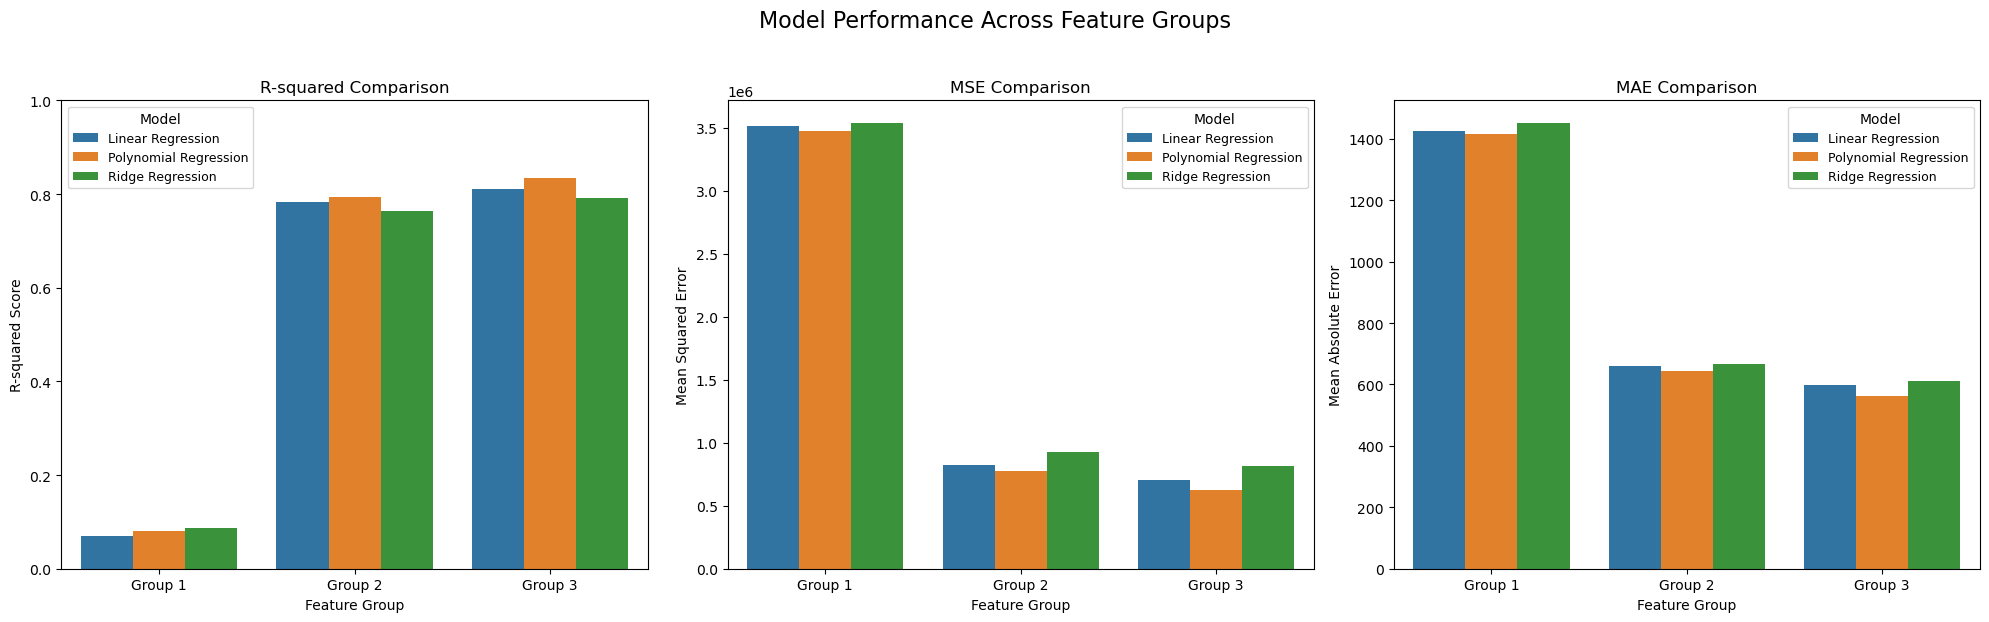

In [431]:
# Grouped bar charts: one panel per metric, comparing every Model and Feature Group combination

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
metric_list = ['R-squared', 'MSE', 'MAE']
titles = ['R-squared Comparison', 'MSE Comparison', 'MAE Comparison']
ylabels = ['R-squared Score', 'Mean Squared Error', 'Mean Absolute Error']

for ax, metric, title, ylabel in zip(axes, metric_list, titles, ylabels):
    subset = all_metrics[all_metrics['Metric'] == metric]
    sns.barplot(data=subset, x='Feature Group', y='Value', hue='Model', ax=ax)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Feature Group')
    if metric == 'R-squared':
        ax.set_ylim(0, 1.0)
    ax.legend(title='Model', loc='best', fontsize=9)

plt.suptitle('Model Performance Across Feature Groups', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

The grouped bar charts above let us compare every model and feature-group combination directly. Higher R-squared values (closer to 1.0) indicate a model explains more of the variance in `TOT_MDCR_STDZD_PYMT_PC`, while lower MSE and MAE values indicate smaller prediction errors.

In [432]:
# Identify the best-performing Model and Feature Group combination based on R-squared
# Group 3 is excluded here since it serves as a baseline feature group rather than a candidate for selecting the best predictive model

candidate_metrics = all_metrics[all_metrics['Feature Group'] != 'Group 3']

best_row = candidate_metrics[candidate_metrics['Metric'] == 'R-squared'].sort_values('Value', ascending=False).iloc[0]
print(f"Best performing combination: {best_row['Model']} using {best_row['Feature Group']}")
print(f"R-squared: {best_row['Value']:.4f}")


matching = candidate_metrics[
    (candidate_metrics['Model'] == best_row['Model']) &
    (candidate_metrics['Feature Group'] == best_row['Feature Group'])
]
matching

Best performing combination: Polynomial Regression using Group 2
R-squared: 0.7943


,Metric,Feature Group,Value,Model
12,R-squared,Group 2,0.794321,Polynomial Regression
13,MSE,Group 2,779686.454405,Polynomial Regression
14,MAE,Group 2,645.085448,Polynomial Regression


### Summary of Model Performance and Core Findings

To systematically model regional healthcare spending variations, we evaluated Linear, Polynomial, and Ridge Regression architectures across our true engineered feature configurations (Feature Group 1: Patient Demographics, and Feature Group 2: System Utilization & Costs), benchmarking their performance against an un-engineered control baseline (Group 3). 

Our comparative evaluation demonstrates that a purely linear assumption underrepresents real-world cost trajectories. Instead, expanding Feature Group 2 into a non-linear space via Polynomial Regression yielded the highest true performance among our engineered feature selections, delivering a standout $R^2$ score of approximately 79.43%. This significant margin improvement confirms that healthcare sector costs exhibit critical, compounding interaction effects that standard linear tracks fail to isolate. 

Additionally, while severe clinical multicollinearity exists within our sector spending metrics, it does not compromise our aggregate forecasting accuracy. Because our primary modeling objective was maximizing the predictive fit of `TOT_MDCR_STDZD_PYMT_PC` rather than isolating independent feature contributions, the Polynomial matrix successfully leverages these joint variances to optimize baseline expenditure forecasts.

### Conclusion & Final Modeling Reflections

By evaluating model variants across different structural configurations, the analysis demonstrates that a Polynomial Regression model utilizing Feature Group 2 yields a strong predictive fit for Medicare payments per capita ($R^2 \approx 79.43\%$). 

However, several deep analytical limitations inherit this framework:

1. **Part-to-Whole Inflation:** Feature Group 2 consists of component healthcare sector costs (Inpatient, Outpatient, etc.) used to predict the total overall spending. This structural relationship heavily guides the model toward high performance, which may obscure real-world variations.
2. **Explanatory Collapse:** As previously mentioned, the independent variables within the cost groups exhibit severe multicollinearity. While expanding the feature space into a polynomial structure successfully captures complex interaction terms to maximize predictive accuracy, it disrupts the stability of individual feature weights. This limits the model's utility as an explanatory tool for targeted policy interventions.
3. **Complexity & Omitted Factors:** Moving to a polynomial feature matrix significantly increases model complexity and degrees of freedom. Furthermore, the model remains blind to vital external cost drivers such as regional chronic disease tracking, local hospital bed capacities, and community Social Determinants of Health (SDoH). Future iterations should focus on incorporating these external clinical indicators.